# Data Source Review

This notebook reviews the initial datasets considered for the dissertation project. The purpose is to assess whether each dataset is suitable for time-series forecasting and energy market risk analysis.

## Libraries

In [98]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

## 1. NESO Historic Demand Data

### 1.1 Purpose of dataset

The NESO Historic Demand Data 2023 dataset is reviewed as the first core dataset for the dissertation. It is expected to provide half-hourly electricity demand, embedded wind generation and embedded solar generation data.

This dataset is relevant because electricity demand, wind generation and solar generation are central variables for analysing energy market conditions and developing a forecasting framework for elevated energy market risk.

### 1.2 File inspection

In [99]:
#Load the CSV and preview it

file = Path.cwd().parent / "Data" / "raw" / "demanddata_2023.csv"

df = pd.read_csv(file)

df.head()

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW
0,01-Jan-23,1,21043,24680,18995,2815,6545,0,15037,0,...,609,903,-896,-451,-529,253,235,998,0,0
1,01-Jan-23,2,21756,25289,19730,2793,6545,0,15037,0,...,596,904,-897,-451,-529,252,157,998,0,0
2,01-Jan-23,3,21348,25269,19327,2773,6545,0,15037,0,...,516,983,-910,-451,-529,253,-219,999,0,0
3,01-Jan-23,4,20586,24574,18589,2753,6545,0,15037,0,...,510,989,-911,-413,-529,254,-298,999,0,0
4,01-Jan-23,5,19781,24135,17806,2712,6545,0,15037,0,...,600,903,-912,-401,-529,253,-679,998,0,0


In [100]:
#Check the size, columns and data types
print("Rows and columns:", df.shape)

print("\nColumn names:")
for col in df.columns:
    print("-", col)

print("\nData types:")
print(df.dtypes)

Rows and columns: (17520, 22)

Column names:
- SETTLEMENT_DATE
- SETTLEMENT_PERIOD
- ND
- TSD
- ENGLAND_WALES_DEMAND
- EMBEDDED_WIND_GENERATION
- EMBEDDED_WIND_CAPACITY
- EMBEDDED_SOLAR_GENERATION
- EMBEDDED_SOLAR_CAPACITY
- NON_BM_STOR
- PUMP_STORAGE_PUMPING
- SCOTTISH_TRANSFER
- IFA_FLOW
- IFA2_FLOW
- BRITNED_FLOW
- MOYLE_FLOW
- EAST_WEST_FLOW
- NEMO_FLOW
- NSL_FLOW
- ELECLINK_FLOW
- VIKING_FLOW
- GREENLINK_FLOW

Data types:
SETTLEMENT_DATE              object
SETTLEMENT_PERIOD             int64
ND                            int64
TSD                           int64
ENGLAND_WALES_DEMAND          int64
EMBEDDED_WIND_GENERATION      int64
EMBEDDED_WIND_CAPACITY        int64
EMBEDDED_SOLAR_GENERATION     int64
EMBEDDED_SOLAR_CAPACITY       int64
NON_BM_STOR                   int64
PUMP_STORAGE_PUMPING          int64
SCOTTISH_TRANSFER             int64
IFA_FLOW                      int64
IFA2_FLOW                     int64
BRITNED_FLOW                  int64
MOYLE_FLOW                   

### 1.3 Date range and frequency

In [101]:
#Create proper date and time columns
df["SETTLEMENT_DATE"] = pd.to_datetime(df["SETTLEMENT_DATE"], format="%d-%b-%y")

df["DATETIME"] = df["SETTLEMENT_DATE"] + pd.to_timedelta((df["SETTLEMENT_PERIOD"] - 1) * 30, unit="m")

df[["SETTLEMENT_DATE", "SETTLEMENT_PERIOD", "DATETIME"]].head()

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,DATETIME
0,2023-01-01,1,2023-01-01 00:00:00
1,2023-01-01,2,2023-01-01 00:30:00
2,2023-01-01,3,2023-01-01 01:00:00
3,2023-01-01,4,2023-01-01 01:30:00
4,2023-01-01,5,2023-01-01 02:00:00


In [102]:
#Check date range and settlement periods
print("Start datetime:", df["DATETIME"].min())
print("End datetime:", df["DATETIME"].max())
print("Number of unique dates:", df["SETTLEMENT_DATE"].nunique())
print("Settlement periods per day:")
print(df.groupby("SETTLEMENT_DATE")["SETTLEMENT_PERIOD"].count().value_counts())

Start datetime: 2023-01-01 00:00:00
End datetime: 2023-12-31 23:30:00
Number of unique dates: 365
Settlement periods per day:
SETTLEMENT_PERIOD
48    363
46      1
50      1
Name: count, dtype: int64


In [103]:
#Find the abnormal settlement period days
periods_per_day = df.groupby("SETTLEMENT_DATE")["SETTLEMENT_PERIOD"].count()

periods_per_day[periods_per_day != 48]

SETTLEMENT_DATE
2023-03-26    46
2023-10-29    50
Name: SETTLEMENT_PERIOD, dtype: int64

The dataset covers the full 2023 calendar year. Most days contain 48 half-hourly settlement periods. Two days have a different number of settlement periods, which aligns with UK daylight saving time changes and will be considered during later preprocessing and modelling.

### 1.4 Missing values

In [104]:
#Check missing values
df.isna().sum()

SETTLEMENT_DATE              0
SETTLEMENT_PERIOD            0
ND                           0
TSD                          0
ENGLAND_WALES_DEMAND         0
EMBEDDED_WIND_GENERATION     0
EMBEDDED_WIND_CAPACITY       0
EMBEDDED_SOLAR_GENERATION    0
EMBEDDED_SOLAR_CAPACITY      0
NON_BM_STOR                  0
PUMP_STORAGE_PUMPING         0
SCOTTISH_TRANSFER            0
IFA_FLOW                     0
IFA2_FLOW                    0
BRITNED_FLOW                 0
MOYLE_FLOW                   0
EAST_WEST_FLOW               0
NEMO_FLOW                    0
NSL_FLOW                     0
ELECLINK_FLOW                0
VIKING_FLOW                  0
GREENLINK_FLOW               0
DATETIME                     0
dtype: int64

No missing values were identified in the original dataset during the initial review.

### 1.5 Useful variables

In [105]:
#Select useful columns for the project
energy = df[[
    "DATETIME",
    "SETTLEMENT_DATE",
    "SETTLEMENT_PERIOD",
    "ND",
    "TSD",
    "ENGLAND_WALES_DEMAND",
    "EMBEDDED_WIND_GENERATION",
    "EMBEDDED_SOLAR_GENERATION"
]].copy()

energy.head()

,DATETIME,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_SOLAR_GENERATION
0,2023-01-01 00:00:00,2023-01-01,1,21043,24680,18995,2815,0
1,2023-01-01 00:30:00,2023-01-01,2,21756,25289,19730,2793,0
2,2023-01-01 01:00:00,2023-01-01,3,21348,25269,19327,2773,0
3,2023-01-01 01:30:00,2023-01-01,4,20586,24574,18589,2753,0
4,2023-01-01 02:00:00,2023-01-01,5,19781,24135,17806,2712,0


In [106]:
#Rename the useful columns
energy = energy.rename(columns={
    "DATETIME": "datetime",
    "SETTLEMENT_DATE": "date",
    "SETTLEMENT_PERIOD": "settlement_period",
    "ND": "national_demand",
    "TSD": "transmission_system_demand",
    "ENGLAND_WALES_DEMAND": "england_wales_demand",
    "EMBEDDED_WIND_GENERATION": "wind_generation",
    "EMBEDDED_SOLAR_GENERATION": "solar_generation"
})

energy.head()

,datetime,date,settlement_period,national_demand,transmission_system_demand,england_wales_demand,wind_generation,solar_generation
0,2023-01-01 00:00:00,2023-01-01,1,21043,24680,18995,2815,0
1,2023-01-01 00:30:00,2023-01-01,2,21756,25289,19730,2793,0
2,2023-01-01 01:00:00,2023-01-01,3,21348,25269,19327,2773,0
3,2023-01-01 01:30:00,2023-01-01,4,20586,24574,18589,2753,0
4,2023-01-01 02:00:00,2023-01-01,5,19781,24135,17806,2712,0


In [107]:
#Create time features
energy["hour"] = energy["datetime"].dt.hour
energy["day"] = energy["datetime"].dt.day
energy["month"] = energy["datetime"].dt.month
energy["weekday"] = energy["datetime"].dt.day_name()
energy["is_weekend"] = energy["weekday"].isin(["Saturday", "Sunday"])

energy.head()

,datetime,date,settlement_period,national_demand,transmission_system_demand,england_wales_demand,wind_generation,solar_generation,hour,day,month,weekday,is_weekend
0,2023-01-01 00:00:00,2023-01-01,1,21043,24680,18995,2815,0,0,1,1,Sunday,True
1,2023-01-01 00:30:00,2023-01-01,2,21756,25289,19730,2793,0,0,1,1,Sunday,True
2,2023-01-01 01:00:00,2023-01-01,3,21348,25269,19327,2773,0,1,1,1,Sunday,True
3,2023-01-01 01:30:00,2023-01-01,4,20586,24574,18589,2753,0,1,1,1,Sunday,True
4,2023-01-01 02:00:00,2023-01-01,5,19781,24135,17806,2712,0,2,1,1,Sunday,True


In [108]:
#Check the cleaned dataset summary
print("Rows and columns:", energy.shape)

print("\nColumn names:")
for col in energy.columns:
    print("-", col)

print("\nMissing values:")
print(energy.isna().sum())

print("\nData types:")
print(energy.dtypes)

Rows and columns: (17520, 13)

Column names:
- datetime
- date
- settlement_period
- national_demand
- transmission_system_demand
- england_wales_demand
- wind_generation
- solar_generation
- hour
- day
- month
- weekday
- is_weekend

Missing values:
datetime                      0
date                          0
settlement_period             0
national_demand               0
transmission_system_demand    0
england_wales_demand          0
wind_generation               0
solar_generation              0
hour                          0
day                           0
month                         0
weekday                       0
is_weekend                    0
dtype: int64

Data types:
datetime                      datetime64[ns]
date                          datetime64[ns]
settlement_period                      int64
national_demand                        int64
transmission_system_demand             int64
england_wales_demand                   int64
wind_generation                      

In [109]:
#Save the cleaned dataset into Data/processed
processed_folder = Path.cwd().parent / "Data" / "processed"

output_file = processed_folder / "neso_demand_wind_solar_2023_clean.csv"

energy.to_csv(output_file, index=False)

print("Saved cleaned file to:")
print(output_file)

Saved cleaned file to:
/Users/tosinjimoh/Downloads/Msc/Lecture Notes/2026-MSc-Dissertation-Project/Data/processed/neso_demand_wind_solar_2023_clean.csv


In [110]:
#Confirm the saved file can be read back properly
check = pd.read_csv(output_file)

print("Rows and columns:", check.shape)
check.head()

Rows and columns: (17520, 13)


,datetime,date,settlement_period,national_demand,transmission_system_demand,england_wales_demand,wind_generation,solar_generation,hour,day,month,weekday,is_weekend
0,2023-01-01 00:00:00,2023-01-01,1,21043,24680,18995,2815,0,0,1,1,Sunday,True
1,2023-01-01 00:30:00,2023-01-01,2,21756,25289,19730,2793,0,0,1,1,Sunday,True
2,2023-01-01 01:00:00,2023-01-01,3,21348,25269,19327,2773,0,1,1,1,Sunday,True
3,2023-01-01 01:30:00,2023-01-01,4,20586,24574,18589,2753,0,1,1,1,Sunday,True
4,2023-01-01 02:00:00,2023-01-01,5,19781,24135,17806,2712,0,2,1,1,Sunday,True


In [111]:
#Create a short data review summary
summary = {
    "raw_file": "demanddata_2023.csv",
    "processed_file": "neso_demand_wind_solar_2023_clean.csv",
    "rows": energy.shape[0],
    "columns": energy.shape[1],
    "start_datetime": energy["datetime"].min(),
    "end_datetime": energy["datetime"].max(),
    "missing_values": energy.isna().sum().sum(),
    "frequency": "Half-hourly settlement periods"
}

summary

{'raw_file': 'demanddata_2023.csv',
 'processed_file': 'neso_demand_wind_solar_2023_clean.csv',
 'rows': 17520,
 'columns': 13,
 'start_datetime': Timestamp('2023-01-01 00:00:00'),
 'end_datetime': Timestamp('2023-12-31 23:30:00'),
 'missing_values': np.int64(0),
 'frequency': 'Half-hourly settlement periods'}

In [112]:
#Save the dataset review summary
tables_folder = Path.cwd().parent / "Outputs" / "tables"
tables_folder.mkdir(parents=True, exist_ok=True)

summary_table = pd.DataFrame([{
    "raw_file": "demanddata_2023.csv",
    "processed_file": "neso_demand_wind_solar_2023_clean.csv",
    "rows": energy.shape[0],
    "columns": energy.shape[1],
    "start_datetime": energy["datetime"].min(),
    "end_datetime": energy["datetime"].max(),
    "missing_values": energy.isna().sum().sum(),
    "frequency": "Half-hourly settlement periods"
}])

summary_file = tables_folder / "neso_2023_data_review_summary.csv"

summary_table.to_csv(summary_file, index=False)

print("Saved summary table to:")
print(summary_file)

summary_table

Saved summary table to:
/Users/tosinjimoh/Downloads/Msc/Lecture Notes/2026-MSc-Dissertation-Project/Outputs/tables/neso_2023_data_review_summary.csv


,raw_file,processed_file,rows,columns,start_datetime,end_datetime,missing_values,frequency
0,demanddata_2023.csv,neso_demand_wind_solar_2023_clean.csv,17520,13,2023-01-01,2023-12-31 23:30:00,0,Half-hourly settlement periods


In [113]:
# Create daily average dataset

daily_energy = energy.groupby("date").agg({
    "national_demand": "mean",
    "wind_generation": "mean",
    "solar_generation": "mean"
}).reset_index()

daily_energy.head()

,date,national_demand,wind_generation,solar_generation
0,2023-01-01,24189.979167,1733.208333,245.729167
1,2023-01-02,27005.520833,1122.416667,733.750000
2,2023-01-03,29646.312500,2927.687500,92.479167
3,2023-01-04,27967.145833,3670.312500,336.729167
4,2023-01-05,29392.500000,2528.229167,228.479167


In [114]:
# Save daily processed dataset

daily_output_file = processed_folder / "neso_demand_wind_solar_2023_daily.csv"

daily_energy.to_csv(daily_output_file, index=False)

print("Saved daily dataset to:")
print(daily_output_file)

Saved daily dataset to:
/Users/tosinjimoh/Downloads/Msc/Lecture Notes/2026-MSc-Dissertation-Project/Data/processed/neso_demand_wind_solar_2023_daily.csv


### 1.6 Initial visual check

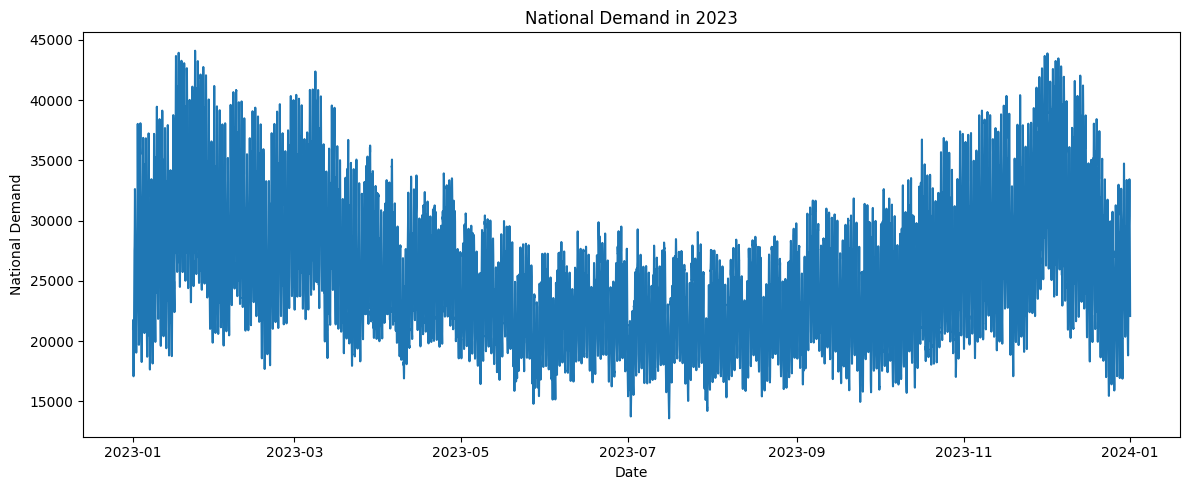

Saved figure to:
/Users/tosinjimoh/Downloads/Msc/Lecture Notes/2026-MSc-Dissertation-Project/Outputs/figures/national_demand_2023.png


In [115]:
# Plot half-hourly national demand

figures_folder = Path.cwd().parent / "Outputs" / "figures"
figures_folder.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 5))
plt.plot(energy["datetime"], energy["national_demand"])
plt.title("National Demand in 2023")
plt.xlabel("Date")
plt.ylabel("National Demand")
plt.tight_layout()

figure_file = figures_folder / "national_demand_2023.png"
plt.savefig(figure_file, dpi=300)
plt.show()

print("Saved figure to:")
print(figure_file)

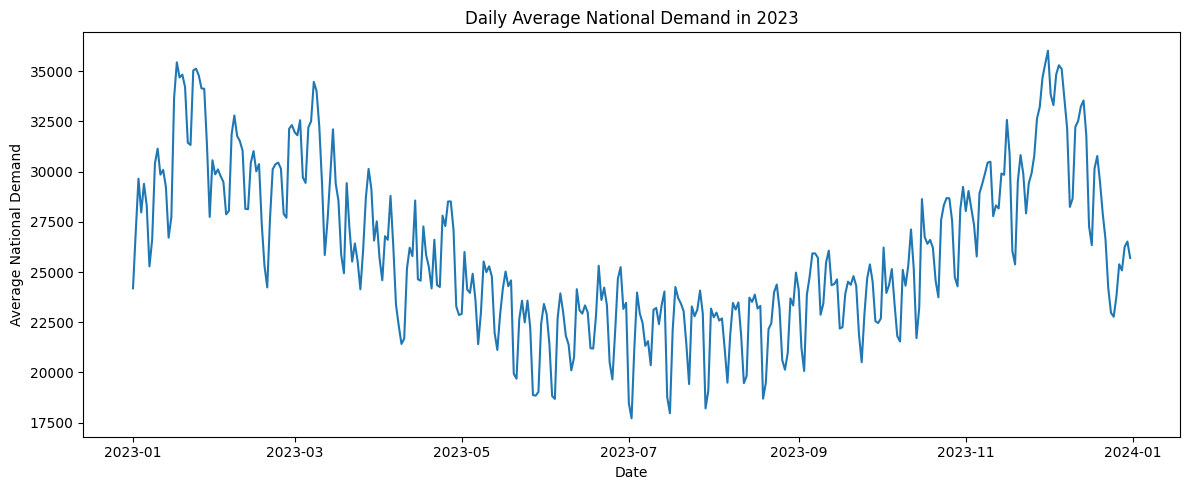

Saved figure to:
/Users/tosinjimoh/Downloads/Msc/Lecture Notes/2026-MSc-Dissertation-Project/Outputs/figures/daily_average_national_demand_2023.png


In [116]:
# Plot daily average national demand

plt.figure(figsize=(12, 5))
plt.plot(daily_energy["date"], daily_energy["national_demand"])
plt.title("Daily Average National Demand in 2023")
plt.xlabel("Date")
plt.ylabel("Average National Demand")
plt.tight_layout()

figure_file = figures_folder / "daily_average_national_demand_2023.png"
plt.savefig(figure_file, dpi=300)
plt.show()

print("Saved figure to:")
print(figure_file)

The daily average demand chart shows clear seasonal variation. Average demand is higher during winter months, lower during summer, and begins to increase again towards the end of the year. This supports the suitability of the dataset for time-series forecasting.

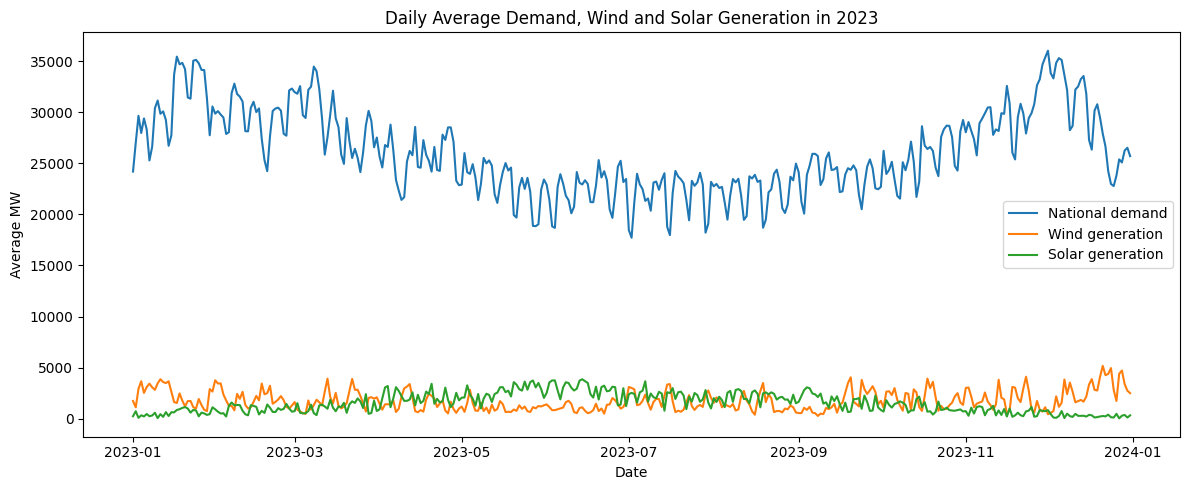

Saved figure to:
/Users/tosinjimoh/Downloads/Msc/Lecture Notes/2026-MSc-Dissertation-Project/Outputs/figures/daily_demand_wind_solar_2023.png


In [117]:
# Plot daily average demand, wind and solar generation

plt.figure(figsize=(12, 5))
plt.plot(daily_energy["date"], daily_energy["national_demand"], label="National demand")
plt.plot(daily_energy["date"], daily_energy["wind_generation"], label="Wind generation")
plt.plot(daily_energy["date"], daily_energy["solar_generation"], label="Solar generation")
plt.title("Daily Average Demand, Wind and Solar Generation in 2023")
plt.xlabel("Date")
plt.ylabel("Average MW")
plt.legend()
plt.tight_layout()

figure_file = figures_folder / "daily_demand_wind_solar_2023.png"
plt.savefig(figure_file, dpi=300)
plt.show()

print("Saved figure to:")
print(figure_file)

The combined daily chart shows that national demand, wind generation and solar generation follow different patterns over the year. National demand is highest in winter and lower during summer, while solar generation is more visible during spring and summer months. Wind generation appears more variable across the year. These differences suggest that demand and renewable generation may provide useful information for later energy market risk analysis.

### 1.7 Suitability assessment

The NESO Historic Demand Data 2023 dataset is suitable for the first stage of the dissertation. It provides complete half-hourly data covering the full 2023 calendar year, with no missing values identified in the selected variables.

The dataset contains key variables relevant to the dissertation, including national demand, transmission system demand, England and Wales demand, embedded wind generation and embedded solar generation. These variables provide an appropriate foundation for analysing demand, renewable generation and energy market conditions.

The initial visual review shows clear seasonal patterns in electricity demand, with higher demand during winter and lower demand during summer. This supports the use of the dataset for time-series forecasting.

Two daylight saving time adjustment days were identified: 26 March 2023 with 46 settlement periods and 29 October 2023 with 50 settlement periods. These will be considered during later preprocessing and modelling.

Overall, this dataset is appropriate for the initial demand and renewable generation component of the dissertation. Additional datasets, including carbon intensity and gas market indicators, will be reviewed separately before being integrated into the wider analysis.

## 2. Carbon Intensity Data

### 2.1 Purpose of dataset

Carbon intensity data will be reviewed as a potential emissions-related indicator for the dissertation. It may help explain periods where the electricity system becomes more carbon intensive, particularly when renewable generation is low or demand is high.

### 2.2 File/API inspection

In [118]:
#Test the Carbon Intensity API for one day
import requests

carbon_api_url = "https://api.carbonintensity.org.uk/intensity/2023-01-01T00:00Z/2023-01-02T00:00Z"

response = requests.get(carbon_api_url)

print("Status code:", response.status_code)

carbon_json = response.json()

carbon_json.keys()

Status code: 200


dict_keys(['data'])

In [119]:
# Preview the first few records returned by the Carbon Intensity API

carbon_json["data"][:5]

[{'from': '2022-12-31T23:30Z',
  'to': '2023-01-01T00:00Z',
  'intensity': {'forecast': 75, 'actual': 65, 'index': 'low'}},
 {'from': '2023-01-01T00:00Z',
  'to': '2023-01-01T00:30Z',
  'intensity': {'forecast': 73, 'actual': 72, 'index': 'low'}},
 {'from': '2023-01-01T00:30Z',
  'to': '2023-01-01T01:00Z',
  'intensity': {'forecast': 63, 'actual': 80, 'index': 'low'}},
 {'from': '2023-01-01T01:00Z',
  'to': '2023-01-01T01:30Z',
  'intensity': {'forecast': 71, 'actual': 72, 'index': 'low'}},
 {'from': '2023-01-01T01:30Z',
  'to': '2023-01-01T02:00Z',
  'intensity': {'forecast': 76, 'actual': 65, 'index': 'low'}}]

In [120]:
# Convert the Carbon Intensity API response into a pandas table

carbon_data = []

for record in carbon_json["data"]:
    carbon_data.append({
        "from": record["from"],
        "to": record["to"],
        "forecast_intensity": record["intensity"]["forecast"],
        "actual_intensity": record["intensity"]["actual"],
        "intensity_index": record["intensity"]["index"]
    })

carbon = pd.DataFrame(carbon_data)

carbon.head()

,from,to,forecast_intensity,actual_intensity,intensity_index
0,2022-12-31T23:30Z,2023-01-01T00:00Z,75,65,low
1,2023-01-01T00:00Z,2023-01-01T00:30Z,73,72,low
2,2023-01-01T00:30Z,2023-01-01T01:00Z,63,80,low
3,2023-01-01T01:00Z,2023-01-01T01:30Z,71,72,low
4,2023-01-01T01:30Z,2023-01-01T02:00Z,76,65,low


In [121]:
# Check the size, columns and data types of the carbon intensity test data

print("Rows and columns:", carbon.shape)

print("\nColumn names:")
for col in carbon.columns:
    print("-", col)

print("\nData types:")
print(carbon.dtypes)

Rows and columns: (49, 5)

Column names:
- from
- to
- forecast_intensity
- actual_intensity
- intensity_index

Data types:
from                  object
to                    object
forecast_intensity     int64
actual_intensity       int64
intensity_index       object
dtype: object


### 2.3 Date range and frequency

In [122]:
# Convert the carbon intensity from/to columns into datetime format

carbon["from"] = pd.to_datetime(carbon["from"])
carbon["to"] = pd.to_datetime(carbon["to"])

carbon.head()

,from,to,forecast_intensity,actual_intensity,intensity_index
0,2022-12-31 23:30:00+00:00,2023-01-01 00:00:00+00:00,75,65,low
1,2023-01-01 00:00:00+00:00,2023-01-01 00:30:00+00:00,73,72,low
2,2023-01-01 00:30:00+00:00,2023-01-01 01:00:00+00:00,63,80,low
3,2023-01-01 01:00:00+00:00,2023-01-01 01:30:00+00:00,71,72,low
4,2023-01-01 01:30:00+00:00,2023-01-01 02:00:00+00:00,76,65,low


In [123]:
# Check the date range and number of records in the carbon intensity test data

print("Start datetime:", carbon["from"].min())
print("End datetime:", carbon["from"].max())
print("Number of records:", len(carbon))

Start datetime: 2022-12-31 23:30:00+00:00
End datetime: 2023-01-01 23:30:00+00:00
Number of records: 49


In [124]:
# Filter the carbon intensity test data to only include 1 January 2023

carbon_test_day = carbon[
    (carbon["from"] >= "2023-01-01 00:00:00+00:00") &
    (carbon["from"] < "2023-01-02 00:00:00+00:00")
].copy()

print("Start datetime:", carbon_test_day["from"].min())
print("End datetime:", carbon_test_day["from"].max())
print("Number of records:", len(carbon_test_day))

carbon_test_day.head()

Start datetime: 2023-01-01 00:00:00+00:00
End datetime: 2023-01-01 23:30:00+00:00
Number of records: 48


,from,to,forecast_intensity,actual_intensity,intensity_index
1,2023-01-01 00:00:00+00:00,2023-01-01 00:30:00+00:00,73,72,low
2,2023-01-01 00:30:00+00:00,2023-01-01 01:00:00+00:00,63,80,low
3,2023-01-01 01:00:00+00:00,2023-01-01 01:30:00+00:00,71,72,low
4,2023-01-01 01:30:00+00:00,2023-01-01 02:00:00+00:00,76,65,low
5,2023-01-01 02:00:00+00:00,2023-01-01 02:30:00+00:00,72,65,low


### 2.4 Missing values

In [125]:
# Check missing values in the filtered carbon intensity test data

carbon_test_day.isna().sum()

from                  0
to                    0
forecast_intensity    0
actual_intensity      0
intensity_index       0
dtype: int64

### 2.5 Useful variables

In [126]:
# Select and rename useful carbon intensity variables

carbon_test = carbon_test_day[[
    "from",
    "to",
    "forecast_intensity",
    "actual_intensity",
    "intensity_index"
]].copy()

carbon_test = carbon_test.rename(columns={
    "from": "datetime_from",
    "to": "datetime_to"
})

carbon_test.head()

,datetime_from,datetime_to,forecast_intensity,actual_intensity,intensity_index
1,2023-01-01 00:00:00+00:00,2023-01-01 00:30:00+00:00,73,72,low
2,2023-01-01 00:30:00+00:00,2023-01-01 01:00:00+00:00,63,80,low
3,2023-01-01 01:00:00+00:00,2023-01-01 01:30:00+00:00,71,72,low
4,2023-01-01 01:30:00+00:00,2023-01-01 02:00:00+00:00,76,65,low
5,2023-01-01 02:00:00+00:00,2023-01-01 02:30:00+00:00,72,65,low


In [127]:
# Check the cleaned carbon intensity test dataset summary

print("Rows and columns:", carbon_test.shape)

print("\nColumn names:")
for col in carbon_test.columns:
    print("-", col)

print("\nMissing values:")
print(carbon_test.isna().sum())

print("\nData types:")
print(carbon_test.dtypes)

Rows and columns: (48, 5)

Column names:
- datetime_from
- datetime_to
- forecast_intensity
- actual_intensity
- intensity_index

Missing values:
datetime_from         0
datetime_to           0
forecast_intensity    0
actual_intensity      0
intensity_index       0
dtype: int64

Data types:
datetime_from         datetime64[ns, UTC]
datetime_to           datetime64[ns, UTC]
forecast_intensity                  int64
actual_intensity                    int64
intensity_index                    object
dtype: object


### 2.6 Initial visual check

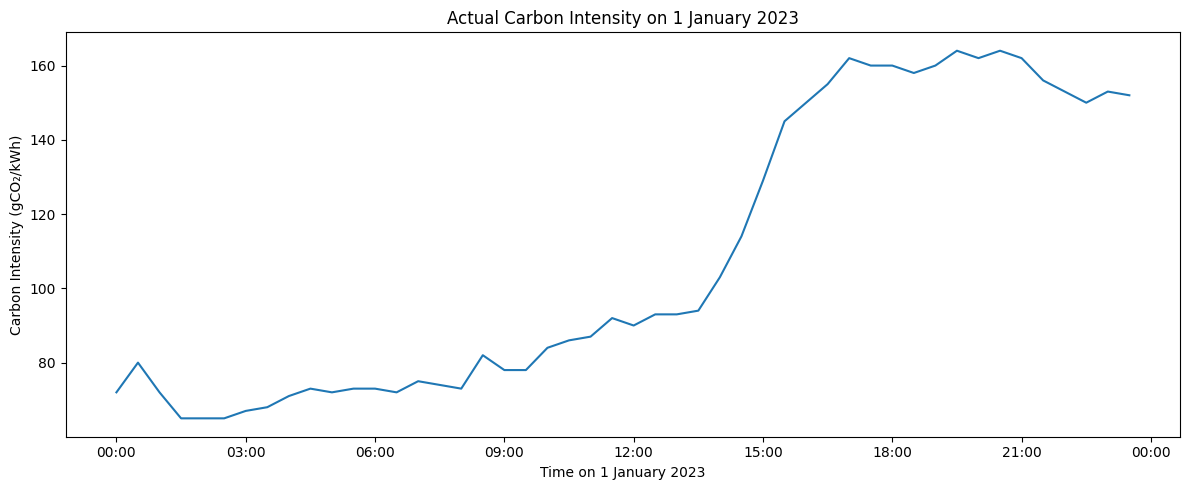

In [128]:
# Plot actual carbon intensity for the one-day test period with hour-only x-axis labels

import matplotlib.dates as mdates

plt.figure(figsize=(12, 5))
plt.plot(carbon_test["datetime_from"], carbon_test["actual_intensity"])
plt.title("Actual Carbon Intensity on 1 January 2023")
plt.xlabel("Time on 1 January 2023")
plt.ylabel("Carbon Intensity (gCO₂/kWh)")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.show()

The one-day carbon intensity test pull returned 48 half-hourly records for 1 January 2023 after filtering out the additional API interval before midnight. The chart shows that actual carbon intensity varies across the day, confirming that the API data can be converted into a usable time-series format.

This initial test suggests that the Carbon Intensity API is suitable for collecting emissions-related data for the dissertation. The next step will be to retrieve the full 2023 carbon intensity dataset and save it as a raw data file.

### 2.7 Suitability assessment

The Carbon Intensity API is suitable for the dissertation because it provides half-hourly carbon intensity data for Great Britain. The one-day test request was successful and returned forecast intensity, actual intensity and intensity index fields.

After filtering the API response to the required date range, the test dataset contained 48 half-hourly records with no missing values. This confirms that the data frequency aligns with the NESO Historic Demand Data, which is also recorded at half-hourly settlement period level.

The actual carbon intensity variable is expected to be the main emissions-related indicator used in the project. This dataset will help support the analysis of elevated energy market risk by identifying periods where the electricity system becomes more carbon intensive.

The next step is to retrieve the full 2023 carbon intensity dataset, save it in the raw data folder, and then prepare a cleaned version for later integration with demand, wind and solar generation data.

### 2.8 Full-year data collection preparation

In [129]:
# Retrieve carbon intensity data for a smaller January 2023 API test

carbon_api_url = "https://api.carbonintensity.org.uk/intensity/2023-01-01T00:00Z/2023-01-31T00:00Z"

response = requests.get(carbon_api_url)

print("Status code:", response.status_code)

carbon_january_json = response.json()

print("Response keys:", carbon_january_json.keys())

if "data" in carbon_january_json:
    print("Number of records returned:", len(carbon_january_json["data"]))
    print(carbon_january_json["data"][:3])
else:
    print(carbon_january_json)

Status code: 200
Response keys: dict_keys(['data'])
Number of records returned: 1441
[{'from': '2022-12-31T23:30Z', 'to': '2023-01-01T00:00Z', 'intensity': {'forecast': 75, 'actual': 65, 'index': 'low'}}, {'from': '2023-01-01T00:00Z', 'to': '2023-01-01T00:30Z', 'intensity': {'forecast': 73, 'actual': 72, 'index': 'low'}}, {'from': '2023-01-01T00:30Z', 'to': '2023-01-01T01:00Z', 'intensity': {'forecast': 63, 'actual': 80, 'index': 'low'}}]


In [130]:
# Convert the January Carbon Intensity API response into a pandas table

carbon_january_data = []

for record in carbon_january_json["data"]:
    carbon_january_data.append({
        "from": record["from"],
        "to": record["to"],
        "forecast_intensity": record["intensity"]["forecast"],
        "actual_intensity": record["intensity"]["actual"],
        "intensity_index": record["intensity"]["index"]
    })

carbon_january = pd.DataFrame(carbon_january_data)

carbon_january.head()

,from,to,forecast_intensity,actual_intensity,intensity_index
0,2022-12-31T23:30Z,2023-01-01T00:00Z,75,65.0,low
1,2023-01-01T00:00Z,2023-01-01T00:30Z,73,72.0,low
2,2023-01-01T00:30Z,2023-01-01T01:00Z,63,80.0,low
3,2023-01-01T01:00Z,2023-01-01T01:30Z,71,72.0,low
4,2023-01-01T01:30Z,2023-01-01T02:00Z,76,65.0,low


In [131]:
# Check the January carbon intensity data range and missing values

carbon_january["from"] = pd.to_datetime(carbon_january["from"])
carbon_january["to"] = pd.to_datetime(carbon_january["to"])

print("Start datetime:", carbon_january["from"].min())
print("End datetime:", carbon_january["from"].max())
print("Number of records:", len(carbon_january))

print("\nMissing values:")
print(carbon_january.isna().sum())

Start datetime: 2022-12-31 23:30:00+00:00
End datetime: 2023-01-30 23:30:00+00:00
Number of records: 1441

Missing values:
from                  0
to                    0
forecast_intensity    0
actual_intensity      5
intensity_index       0
dtype: int64


In [132]:
# Display January records where actual carbon intensity is missing

missing_actual_january = carbon_january[carbon_january["actual_intensity"].isna()]

missing_actual_january

,from,to,forecast_intensity,actual_intensity,intensity_index
1228,2023-01-26 13:30:00+00:00,2023-01-26 14:00:00+00:00,214,NaN,high
1229,2023-01-26 14:00:00+00:00,2023-01-26 14:30:00+00:00,225,NaN,high
1230,2023-01-26 14:30:00+00:00,2023-01-26 15:00:00+00:00,223,NaN,high
1231,2023-01-26 15:00:00+00:00,2023-01-26 15:30:00+00:00,218,NaN,high
1232,2023-01-26 15:30:00+00:00,2023-01-26 16:00:00+00:00,212,NaN,high


In [133]:
# Filter January carbon intensity data to the requested date range only

carbon_january_filtered = carbon_january[
    (carbon_january["from"] >= "2023-01-01 00:00:00+00:00") &
    (carbon_january["from"] < "2023-01-31 00:00:00+00:00")
].copy()

print("Start datetime:", carbon_january_filtered["from"].min())
print("End datetime:", carbon_january_filtered["from"].max())
print("Number of records:", len(carbon_january_filtered))

print("\nMissing values:")
print(carbon_january_filtered.isna().sum())

Start datetime: 2023-01-01 00:00:00+00:00
End datetime: 2023-01-30 23:30:00+00:00
Number of records: 1440

Missing values:
from                  0
to                    0
forecast_intensity    0
actual_intensity      5
intensity_index       0
dtype: int64


The January test request confirmed that the Carbon Intensity API can retrieve a larger date range successfully, provided the range is below the API limit of 31 days. The API returned one additional half-hour interval before the requested start time, so the data was filtered to begin exactly at 1 January 2023 00:00.

After filtering, the January sample contained 1,440 half-hourly records, which is correct for 30 days of half-hourly data. Five missing values were identified in the actual carbon intensity column, all within a short period on 26 January 2023. This will be considered during the later cleaning stage.

In [134]:
# Retrieve carbon intensity data for the full 2023 year in 30-day chunks

carbon_2023_data = []

start_date = pd.Timestamp("2023-01-01")
final_date = pd.Timestamp("2024-01-01")

while start_date < final_date:
    end_date = start_date + pd.Timedelta(days=30)

    if end_date > final_date:
        end_date = final_date

    carbon_api_url = f"https://api.carbonintensity.org.uk/intensity/{start_date:%Y-%m-%dT00:00Z}/{end_date:%Y-%m-%dT00:00Z}"

    response = requests.get(carbon_api_url)
    carbon_json = response.json()

    print(start_date.date(), "to", end_date.date(), "-", response.status_code)

    for record in carbon_json["data"]:
        carbon_2023_data.append({
            "from": record["from"],
            "to": record["to"],
            "forecast_intensity": record["intensity"]["forecast"],
            "actual_intensity": record["intensity"]["actual"],
            "intensity_index": record["intensity"]["index"]
        })

    start_date = end_date

carbon_2023 = pd.DataFrame(carbon_2023_data)

carbon_2023.head()

2023-01-01 to 2023-01-31 - 200
2023-01-31 to 2023-03-02 - 200
2023-03-02 to 2023-04-01 - 200
2023-04-01 to 2023-05-01 - 200
2023-05-01 to 2023-05-31 - 200
2023-05-31 to 2023-06-30 - 200
2023-06-30 to 2023-07-30 - 200
2023-07-30 to 2023-08-29 - 200
2023-08-29 to 2023-09-28 - 200
2023-09-28 to 2023-10-28 - 200
2023-10-28 to 2023-11-27 - 200
2023-11-27 to 2023-12-27 - 200
2023-12-27 to 2024-01-01 - 200


,from,to,forecast_intensity,actual_intensity,intensity_index
0,2022-12-31T23:30Z,2023-01-01T00:00Z,75,65.0,low
1,2023-01-01T00:00Z,2023-01-01T00:30Z,73,72.0,low
2,2023-01-01T00:30Z,2023-01-01T01:00Z,63,80.0,low
3,2023-01-01T01:00Z,2023-01-01T01:30Z,71,72.0,low
4,2023-01-01T01:30Z,2023-01-01T02:00Z,76,65.0,low


In [158]:
# Save the raw full-year Carbon Intensity API output before cleaning

raw_folder = Path.cwd().parent / "Data" / "raw"
raw_folder.mkdir(parents=True, exist_ok=True)

carbon_raw_file = raw_folder / "carbon_intensity_2023_raw.csv"

carbon_2023.to_csv(carbon_raw_file, index=False)

print("Saved raw carbon intensity file to:")
print(carbon_raw_file)

Saved raw carbon intensity file to:
/Users/tosinjimoh/Downloads/Msc/Lecture Notes/2026-MSc-Dissertation-Project/Data/raw/carbon_intensity_2023_raw.csv


In [135]:
# Clean the full 2023 carbon intensity dataset

carbon_2023["from"] = pd.to_datetime(carbon_2023["from"])
carbon_2023["to"] = pd.to_datetime(carbon_2023["to"])

carbon_2023_clean = carbon_2023[
    (carbon_2023["from"] >= "2023-01-01 00:00:00+00:00") &
    (carbon_2023["from"] < "2024-01-01 00:00:00+00:00")
].copy()

carbon_2023_clean = carbon_2023_clean.drop_duplicates(subset=["from"])

print("Start datetime:", carbon_2023_clean["from"].min())
print("End datetime:", carbon_2023_clean["from"].max())
print("Number of records:", len(carbon_2023_clean))

print("\nMissing values:")
print(carbon_2023_clean.isna().sum())

carbon_2023_clean.head()

Start datetime: 2023-01-01 00:00:00+00:00
End datetime: 2023-12-31 23:30:00+00:00
Number of records: 17429

Missing values:
from                  0
to                    0
forecast_intensity    0
actual_intensity      5
intensity_index       0
dtype: int64


,from,to,forecast_intensity,actual_intensity,intensity_index
1,2023-01-01 00:00:00+00:00,2023-01-01 00:30:00+00:00,73,72.0,low
2,2023-01-01 00:30:00+00:00,2023-01-01 01:00:00+00:00,63,80.0,low
3,2023-01-01 01:00:00+00:00,2023-01-01 01:30:00+00:00,71,72.0,low
4,2023-01-01 01:30:00+00:00,2023-01-01 02:00:00+00:00,76,65.0,low
5,2023-01-01 02:00:00+00:00,2023-01-01 02:30:00+00:00,72,65.0,low


In [136]:
# Identify missing half-hour timestamps in the full 2023 carbon intensity dataset

expected_datetimes = pd.date_range(
    start="2023-01-01 00:00:00+00:00",
    end="2023-12-31 23:30:00+00:00",
    freq="30min"
)

actual_datetimes = carbon_2023_clean["from"]

missing_datetimes = expected_datetimes.difference(actual_datetimes)

print("Expected records:", len(expected_datetimes))
print("Actual records:", len(actual_datetimes))
print("Missing records:", len(missing_datetimes))

missing_datetimes[:20]

Expected records: 17520
Actual records: 17429
Missing records: 91


DatetimeIndex(['2023-10-20 22:00:00+00:00', '2023-10-20 22:30:00+00:00',
               '2023-10-20 23:00:00+00:00', '2023-10-20 23:30:00+00:00',
               '2023-10-21 00:00:00+00:00', '2023-10-21 00:30:00+00:00',
               '2023-10-21 01:00:00+00:00', '2023-10-21 01:30:00+00:00',
               '2023-10-21 02:00:00+00:00', '2023-10-21 02:30:00+00:00',
               '2023-10-21 03:00:00+00:00', '2023-10-21 03:30:00+00:00',
               '2023-10-21 04:00:00+00:00', '2023-10-21 04:30:00+00:00',
               '2023-10-21 05:00:00+00:00', '2023-10-21 05:30:00+00:00',
               '2023-10-21 06:00:00+00:00', '2023-10-21 06:30:00+00:00',
               '2023-10-21 07:00:00+00:00', '2023-10-21 07:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='30min')

In [137]:
# Summarise missing carbon intensity timestamps by date

missing_summary = pd.DataFrame({
    "missing_datetime": missing_datetimes
})

missing_summary["date"] = missing_summary["missing_datetime"].dt.date

missing_summary.groupby("date").size()

date
2023-10-20     4
2023-10-21    48
2023-10-22    39
dtype: int64

In [138]:
# Re-pull the missing October carbon intensity period

carbon_api_url = "https://api.carbonintensity.org.uk/intensity/2023-10-20T00:00Z/2023-10-23T00:00Z"

response = requests.get(carbon_api_url)

print("Status code:", response.status_code)

carbon_october_gap_json = response.json()

print("Response keys:", carbon_october_gap_json.keys())

if "data" in carbon_october_gap_json:
    print("Number of records returned:", len(carbon_october_gap_json["data"]))
    print(carbon_october_gap_json["data"][:3])
else:
    print(carbon_october_gap_json)

Status code: 200
Response keys: dict_keys(['data'])
Number of records returned: 54
[{'from': '2023-10-19T23:30Z', 'to': '2023-10-20T00:00Z', 'intensity': {'forecast': 82, 'actual': 65, 'index': 'low'}}, {'from': '2023-10-20T00:00Z', 'to': '2023-10-20T00:30Z', 'intensity': {'forecast': 82, 'actual': 69, 'index': 'low'}}, {'from': '2023-10-20T00:30Z', 'to': '2023-10-20T01:00Z', 'intensity': {'forecast': 80, 'actual': 72, 'index': 'low'}}]


In [139]:
# Convert the October gap API response into a pandas table

carbon_october_gap_data = []

for record in carbon_october_gap_json["data"]:
    carbon_october_gap_data.append({
        "from": record["from"],
        "to": record["to"],
        "forecast_intensity": record["intensity"]["forecast"],
        "actual_intensity": record["intensity"]["actual"],
        "intensity_index": record["intensity"]["index"]
    })

carbon_october_gap = pd.DataFrame(carbon_october_gap_data)

carbon_october_gap["from"] = pd.to_datetime(carbon_october_gap["from"])
carbon_october_gap["to"] = pd.to_datetime(carbon_october_gap["to"])

carbon_october_gap = carbon_october_gap[
    (carbon_october_gap["from"] >= "2023-10-20 00:00:00+00:00") &
    (carbon_october_gap["from"] < "2023-10-23 00:00:00+00:00")
].copy()

print("Start datetime:", carbon_october_gap["from"].min())
print("End datetime:", carbon_october_gap["from"].max())
print("Number of records:", len(carbon_october_gap))

carbon_october_gap.head()

Start datetime: 2023-10-20 00:00:00+00:00
End datetime: 2023-10-22 23:30:00+00:00
Number of records: 53


,from,to,forecast_intensity,actual_intensity,intensity_index
1,2023-10-20 00:00:00+00:00,2023-10-20 00:30:00+00:00,82,69,low
2,2023-10-20 00:30:00+00:00,2023-10-20 01:00:00+00:00,80,72,low
3,2023-10-20 01:00:00+00:00,2023-10-20 01:30:00+00:00,79,69,low
4,2023-10-20 01:30:00+00:00,2023-10-20 02:00:00+00:00,76,70,low
5,2023-10-20 02:00:00+00:00,2023-10-20 02:30:00+00:00,75,65,low


In [140]:
# Patch the October gap records into the full carbon intensity dataset

carbon_2023_clean = pd.concat(
    [carbon_2023_clean, carbon_october_gap],
    ignore_index=True
)

carbon_2023_clean = carbon_2023_clean.drop_duplicates(subset=["from"])
carbon_2023_clean = carbon_2023_clean.sort_values("from").reset_index(drop=True)

print("Start datetime:", carbon_2023_clean["from"].min())
print("End datetime:", carbon_2023_clean["from"].max())
print("Number of records:", len(carbon_2023_clean))

print("\nMissing values:")
print(carbon_2023_clean.isna().sum())

Start datetime: 2023-01-01 00:00:00+00:00
End datetime: 2023-12-31 23:30:00+00:00
Number of records: 17429

Missing values:
from                  0
to                    0
forecast_intensity    0
actual_intensity      5
intensity_index       0
dtype: int64


In [141]:
# Re-check missing half-hour timestamps after patching the October gap

expected_datetimes = pd.date_range(
    start="2023-01-01 00:00:00+00:00",
    end="2023-12-31 23:30:00+00:00",
    freq="30min"
)

actual_datetimes = carbon_2023_clean["from"]

missing_datetimes = expected_datetimes.difference(actual_datetimes)

print("Expected records:", len(expected_datetimes))
print("Actual records:", len(actual_datetimes))
print("Missing records:", len(missing_datetimes))

missing_summary = pd.DataFrame({
    "missing_datetime": missing_datetimes
})

missing_summary["date"] = missing_summary["missing_datetime"].dt.date

missing_summary.groupby("date").size()

Expected records: 17520
Actual records: 17429
Missing records: 91


date
2023-10-20     4
2023-10-21    48
2023-10-22    39
dtype: int64

The full 2023 carbon intensity API pull returned 17,429 records after filtering to the 2023 calendar year and removing duplicate timestamps. A complete half-hourly 2023 dataset would contain 17,520 records, meaning 91 half-hourly timestamps are missing.

The missing timestamps are concentrated between 20 October and 22 October 2023. A separate API request was made for this period, but it did not return the missing records. This suggests that the gap is likely due to the source API data rather than the collection code.

The missing periods will be handled during the later data cleaning and integration stage, either through interpolation, use of forecast intensity where appropriate, or careful exclusion depending on the modelling requirements.

In [142]:
# Save the available full-year carbon intensity data to the raw data folder

raw_folder = Path.cwd().parent / "Data" / "raw"

carbon_raw_file = raw_folder / "carbon_intensity_2023_raw.csv"

carbon_2023_clean.to_csv(carbon_raw_file, index=False)

print("Saved carbon intensity raw file to:")
print(carbon_raw_file)

Saved carbon intensity raw file to:
/Users/tosinjimoh/Downloads/Msc/Lecture Notes/2026-MSc-Dissertation-Project/Data/raw/carbon_intensity_2023_raw.csv


In [143]:
# Create a carbon intensity data review summary

carbon_summary = {
    "raw_file": "carbon_intensity_2023_raw.csv",
    "rows": carbon_2023_clean.shape[0],
    "columns": carbon_2023_clean.shape[1],
    "start_datetime": carbon_2023_clean["from"].min(),
    "end_datetime": carbon_2023_clean["from"].max(),
    "missing_actual_intensity_values": carbon_2023_clean["actual_intensity"].isna().sum(),
    "missing_half_hour_timestamps": len(missing_datetimes),
    "frequency": "Half-hourly"
}

carbon_summary

{'raw_file': 'carbon_intensity_2023_raw.csv',
 'rows': 17429,
 'columns': 5,
 'start_datetime': Timestamp('2023-01-01 00:00:00+0000', tz='UTC'),
 'end_datetime': Timestamp('2023-12-31 23:30:00+0000', tz='UTC'),
 'missing_actual_intensity_values': np.int64(5),
 'missing_half_hour_timestamps': 91,
 'frequency': 'Half-hourly'}

In [144]:
# Save the cleaned full-year carbon intensity dataset into Data/processed

processed_folder = Path.cwd().parent / "Data" / "processed"
processed_folder.mkdir(parents=True, exist_ok=True)

carbon_processed_file = processed_folder / "carbon_intensity_2023_clean.csv"

carbon_2023_clean.to_csv(carbon_processed_file, index=False)

print("Saved cleaned carbon intensity file to:")
print(carbon_processed_file)

Saved cleaned carbon intensity file to:
/Users/tosinjimoh/Downloads/Msc/Lecture Notes/2026-MSc-Dissertation-Project/Data/processed/carbon_intensity_2023_clean.csv


In [145]:
# Save the carbon intensity data review summary

tables_folder = Path.cwd().parent / "Outputs" / "tables"
tables_folder.mkdir(parents=True, exist_ok=True)

carbon_summary_table = pd.DataFrame([{
    "source": "Carbon Intensity API",
    "processed_file": "carbon_intensity_2023_clean.csv",
    "rows": carbon_2023_clean.shape[0],
    "columns": carbon_2023_clean.shape[1],
    "start_datetime": carbon_2023_clean["from"].min(),
    "end_datetime": carbon_2023_clean["from"].max(),
    "missing_actual_intensity_values": carbon_2023_clean["actual_intensity"].isna().sum(),
    "missing_half_hour_timestamps": len(missing_datetimes),
    "frequency": "Half-hourly",
    "unit": "gCO2/kWh"
}])

carbon_summary_file = tables_folder / "carbon_intensity_2023_data_review_summary.csv"

carbon_summary_table.to_csv(carbon_summary_file, index=False)

print("Saved carbon intensity summary table to:")
print(carbon_summary_file)

carbon_summary_table

Saved carbon intensity summary table to:
/Users/tosinjimoh/Downloads/Msc/Lecture Notes/2026-MSc-Dissertation-Project/Outputs/tables/carbon_intensity_2023_data_review_summary.csv


,source,processed_file,rows,columns,start_datetime,end_datetime,missing_actual_intensity_values,missing_half_hour_timestamps,frequency,unit
0,Carbon Intensity API,carbon_intensity_2023_clean.csv,17429,5,2023-01-01 00:00:00+00:00,2023-12-31 23:30:00+00:00,5,91,Half-hourly,gCO2/kWh


### Carbon Intensity Dataset Review Summary

The Carbon Intensity API was reviewed as the second dataset for the dissertation. The dataset provides half-hourly carbon intensity data for Great Britain, including forecast intensity, actual intensity and an intensity index.

A one-day test request was first carried out to confirm that the API response could be converted into a usable time-series table. The test returned 48 half-hourly records for 1 January 2023 after filtering out the additional interval before midnight. The initial visual check showed that actual carbon intensity varied throughout the day, supporting the suitability of the dataset for time-series analysis.

The full 2023 dataset was then collected in 30-day chunks because the API restricts requests to date ranges below 31 days. After filtering to the 2023 calendar year and removing duplicate timestamps, the available dataset contained 17,429 records and 5 columns. The dataset covers 1 January 2023 00:00 to 31 December 2023 23:30.

A complete half-hourly dataset for 2023 would contain 17,520 records. Therefore, 91 half-hourly timestamps are missing from the API data. These missing timestamps are concentrated between 20 October and 22 October 2023. A separate API request was made for this period, but the missing records were not returned, suggesting that the gap is likely due to the source API data rather than the collection code.

There are also 5 missing values in the actual carbon intensity column. These occur within a short period on 26 January 2023. The missing timestamps and missing actual intensity values will be handled during the later data cleaning and integration stage.

The available carbon intensity data was saved as `Data/raw/carbon_intensity_2023_raw.csv`, and the dataset review summary was saved as `Outputs/tables/carbon_intensity_2023_data_review_summary.csv`.


## 3. Gas Market Indicators

### 3.1 Purpose of dataset

Gas market indicators are reviewed as the third dataset area for the dissertation. Gas is relevant because gas-fired generation can influence electricity market conditions, especially during periods of high demand, low renewable generation or tighter supply conditions.

This dataset area is relevant to the project because gas market pressure may act as an additional indicator of elevated energy market risk. Potential variables include gas system demand, gas supply, linepack and gas price indicators such as the System Average Price of gas.

### 3.2 Potential data sources

The initial gas market data review will consider two main public sources:

1. National Gas Transmission Data Portal: provides data for the National Transmission System, including supply, demand, linepack and gas flow information.

2. ONS System Average Price of gas: provides daily System Average Price data and a seven-day rolling average for gas traded in Great Britain on the On-the-Day Commodity Market.

These sources will be reviewed to identify which gas market indicator is most suitable for integration with the existing demand, renewable generation and carbon intensity datasets.

### 3.3 ONS System Average Price of Gas

The ONS System Average Price of gas dataset is reviewed as the first gas market indicator for the dissertation. The dataset provides daily gas price information for Great Britain, including the System Average Price and a seven-day rolling average.

This dataset is relevant because gas prices can act as an indicator of gas market pressure. Higher gas prices may reflect tighter market conditions, increased demand, supply constraints or wider market volatility. This is important for the dissertation because gas-fired generation can influence electricity system risk during periods of high demand or low renewable generation.

In [146]:
# Load and preview the ONS gas price data sheet

gas = pd.read_excel(gas_file, sheet_name="Data")

print("Rows and columns:", gas.shape)

gas.head(10)

Rows and columns: (2181, 10)


,System Average Price (SAP) of Gas,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,SAP Actual Day and preceding 7 day rolling ave...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,This worksheet contains one table.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Source: National Gas Transmission,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Date,SAP actual day\n(p/kWh),SAP preceding seven-day rolling average\n(p/kWh),NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-01-01 00:00:00,1.7083,1.8474,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2018-01-02 00:00:00,1.7331,1.8318,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2018-01-03 00:00:00,1.7663,1.8019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2018-01-04 00:00:00,1.7719,1.7835,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2018-01-05 00:00:00,1.7601,1.7608,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2018-01-06 00:00:00,1.7186,1.7554,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [147]:
# Load the ONS gas price data using the correct header row

gas = pd.read_excel(gas_file, sheet_name="Data", header=4)

print("Rows and columns:", gas.shape)

gas.head()

Rows and columns: (2177, 10)


,Date,SAP actual day\n(p/kWh),SAP preceding seven-day rolling average\n(p/kWh),Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,2018-01-01,1.7083,1.8474,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-02,1.7331,1.8318,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-01-03,1.7663,1.8019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-01-04,1.7719,1.7835,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-01-05,1.7601,1.7608,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [148]:
# Keep only the useful ONS gas price columns

gas = gas[[
    "Date",
    "SAP actual day\n(p/kWh)",
    "SAP preceding seven-day rolling average\n(p/kWh)"
]].copy()

gas.head()

,Date,SAP actual day\n(p/kWh),SAP preceding seven-day rolling average\n(p/kWh)
0,2018-01-01,1.7083,1.8474
1,2018-01-02,1.7331,1.8318
2,2018-01-03,1.7663,1.8019
3,2018-01-04,1.7719,1.7835
4,2018-01-05,1.7601,1.7608


In [149]:
# Rename the ONS gas price columns

gas = gas.rename(columns={
    "Date": "date",
    "SAP actual day\n(p/kWh)": "sap_actual_p_per_kwh",
    "SAP preceding seven-day rolling average\n(p/kWh)": "sap_7day_rolling_average_p_per_kwh"
})

gas.head()

,date,sap_actual_p_per_kwh,sap_7day_rolling_average_p_per_kwh
0,2018-01-01,1.7083,1.8474
1,2018-01-02,1.7331,1.8318
2,2018-01-03,1.7663,1.8019
3,2018-01-04,1.7719,1.7835
4,2018-01-05,1.7601,1.7608


In [150]:
# Check the date range, size and missing values for the ONS gas price data

gas["date"] = pd.to_datetime(gas["date"])

print("Rows and columns:", gas.shape)
print("Start date:", gas["date"].min())
print("End date:", gas["date"].max())

print("\nMissing values:")
print(gas.isna().sum())

print("\nData types:")
print(gas.dtypes)

Rows and columns: (2177, 3)
Start date: 2018-01-01 00:00:00
End date: 2023-12-17 00:00:00

Missing values:
date                                  0
sap_actual_p_per_kwh                  0
sap_7day_rolling_average_p_per_kwh    0
dtype: int64

Data types:
date                                  datetime64[ns]
sap_actual_p_per_kwh                         float64
sap_7day_rolling_average_p_per_kwh           float64
dtype: object


In [151]:
# Filter the ONS gas price data to 2023 only

gas_2023 = gas[
    (gas["date"] >= "2023-01-01") &
    (gas["date"] <= "2023-12-31")
].copy()

print("Rows and columns:", gas_2023.shape)
print("Start date:", gas_2023["date"].min())
print("End date:", gas_2023["date"].max())

print("\nMissing values:")
print(gas_2023.isna().sum())

gas_2023.head()

Rows and columns: (351, 3)
Start date: 2023-01-01 00:00:00
End date: 2023-12-17 00:00:00

Missing values:
date                                  0
sap_actual_p_per_kwh                  0
sap_7day_rolling_average_p_per_kwh    0
dtype: int64


,date,sap_actual_p_per_kwh,sap_7day_rolling_average_p_per_kwh
1826,2023-01-01,5.7764,5.9602
1827,2023-01-02,5.9978,5.9704
1828,2023-01-03,5.6898,5.9326
1829,2023-01-04,5.0746,5.8222
1830,2023-01-05,5.0837,5.7133


In [152]:
# Check the 2023 ONS gas price dataset coverage

print("Rows and columns:", gas_2023.shape)
print("Start date:", gas_2023["date"].min())
print("End date:", gas_2023["date"].max())
print("Number of unique dates:", gas_2023["date"].nunique())

print("\nMissing values:")
print(gas_2023.isna().sum())

Rows and columns: (351, 3)
Start date: 2023-01-01 00:00:00
End date: 2023-12-17 00:00:00
Number of unique dates: 351

Missing values:
date                                  0
sap_actual_p_per_kwh                  0
sap_7day_rolling_average_p_per_kwh    0
dtype: int64


In [153]:
# Save the cleaned 2023 ONS gas price dataset

processed_folder = Path.cwd().parent / "Data" / "processed"

gas_output_file = processed_folder / "ons_sap_gas_2023_clean.csv"

gas_2023.to_csv(gas_output_file, index=False)

print("Saved cleaned gas price file to:")
print(gas_output_file)

Saved cleaned gas price file to:
/Users/tosinjimoh/Downloads/Msc/Lecture Notes/2026-MSc-Dissertation-Project/Data/processed/ons_sap_gas_2023_clean.csv


In [154]:
# Create a gas price data review summary

gas_summary = {
    "raw_file": "ons_sap_gas_2023_raw.xlsx",
    "processed_file": "ons_sap_gas_2023_clean.csv",
    "rows": gas_2023.shape[0],
    "columns": gas_2023.shape[1],
    "start_date": gas_2023["date"].min(),
    "end_date": gas_2023["date"].max(),
    "missing_values": gas_2023.isna().sum().sum(),
    "frequency": "Daily"
}

gas_summary

{'raw_file': 'ons_sap_gas_2023_raw.xlsx',
 'processed_file': 'ons_sap_gas_2023_clean.csv',
 'rows': 351,
 'columns': 3,
 'start_date': Timestamp('2023-01-01 00:00:00'),
 'end_date': Timestamp('2023-12-17 00:00:00'),
 'missing_values': np.int64(0),
 'frequency': 'Daily'}

In [155]:
# Save the gas price data review summary

tables_folder = Path.cwd().parent / "Outputs" / "tables"
tables_folder.mkdir(parents=True, exist_ok=True)

gas_summary_table = pd.DataFrame([{
    "raw_file": "ons_sap_gas_2023_raw.xlsx",
    "processed_file": "ons_sap_gas_2023_clean.csv",
    "rows": gas_2023.shape[0],
    "columns": gas_2023.shape[1],
    "start_date": gas_2023["date"].min(),
    "end_date": gas_2023["date"].max(),
    "missing_values": gas_2023.isna().sum().sum(),
    "frequency": "Daily"
}])

gas_summary_file = tables_folder / "ons_sap_gas_2023_data_review_summary.csv"

gas_summary_table.to_csv(gas_summary_file, index=False)

print("Saved gas price summary table to:")
print(gas_summary_file)

gas_summary_table

Saved gas price summary table to:
/Users/tosinjimoh/Downloads/Msc/Lecture Notes/2026-MSc-Dissertation-Project/Outputs/tables/ons_sap_gas_2023_data_review_summary.csv


,raw_file,processed_file,rows,columns,start_date,end_date,missing_values,frequency
0,ons_sap_gas_2023_raw.xlsx,ons_sap_gas_2023_clean.csv,351,3,2023-01-01,2023-12-17,0,Daily


### 3.4 Missing values

No missing values were identified in the selected ONS gas price variables for the 2023 subset.

The dataset contains 351 daily records from 1 January 2023 to 17 December 2023. This means the file does not cover the full 2023 calendar year, as records from 18 December 2023 to 31 December 2023 are not included in the downloaded ONS file.

This shorter coverage period will be considered during the later data integration stage.

### 3.5 Useful variables

The useful variables selected from the ONS System Average Price of gas dataset are:

- `date`: the daily date of the gas price observation.
- `sap_actual_p_per_kwh`: the actual System Average Price of gas for the day, measured in pence per kilowatt-hour.
- `sap_7day_rolling_average_p_per_kwh`: the preceding seven-day rolling average of the System Average Price, also measured in pence per kilowatt-hour.

The actual SAP value will be useful as a daily gas market pressure indicator, while the seven-day rolling average provides a smoother measure of recent gas price trends.

### 3.6 Suitability assessment

The ONS System Average Price of gas dataset is suitable as an initial gas market indicator for the dissertation. It provides a clear and commercially interpretable measure of gas market pressure through the daily System Average Price of gas.

The dataset is easier to integrate than more technical gas system variables such as linepack or gas flow data. It is also relevant to the project because higher gas prices may indicate tighter gas market conditions, which can affect electricity market risk when gas-fired generation is needed to support demand.

The cleaned 2023 subset contains 351 daily records and 3 selected variables, with no missing values in the selected columns. The main limitation is that the downloaded file only covers the period from 1 January 2023 to 17 December 2023, rather than the full 2023 calendar year.

Overall, this dataset is appropriate for representing gas market pressure in the initial version of the dissertation dataset. The frequency difference between the daily gas price data and the half-hourly electricity and carbon intensity datasets will be addressed during the later data integration stage.

## 4. Overall Data Source Review Summary

This notebook reviewed the initial datasets selected for the dissertation project. The aim was to assess whether each dataset is suitable for later cleaning, integration and time-series forecasting.

The NESO Historic Demand Data 2023 dataset provides the main electricity demand and renewable generation variables. It contains half-hourly records for the full 2023 calendar year, with 17,520 rows and no missing values in the selected variables. The dataset includes national demand, transmission system demand, England and Wales demand, embedded wind generation and embedded solar generation.

The Carbon Intensity API provides half-hourly carbon intensity data for Great Britain. The available 2023 dataset contains 17,429 records after filtering and duplicate removal. A complete half-hourly 2023 dataset would contain 17,520 records, meaning 91 timestamps are missing, mainly between 20 October and 22 October 2023. Five missing actual intensity values were also identified on 26 January 2023. These issues will be handled during the later cleaning and integration stage.

The ONS System Average Price of Gas dataset provides daily gas price data for Great Britain. The 2023 subset contains 351 daily records from 1 January 2023 to 17 December 2023, with no missing values in the selected variables. The daily gas price data will be useful as a gas market pressure indicator, although its daily frequency and shorter date coverage will need to be addressed during data integration.

Overall, the reviewed datasets are suitable for the initial dissertation dataset. Together, they provide electricity demand, renewable generation, carbon intensity and gas market pressure indicators. The next stage of the project will focus on cleaning and integrating these datasets into a single analysis-ready dataset for exploratory analysis and forecasting.

In [156]:
# Create an overall data source review summary table

overall_summary = pd.DataFrame([
    {
        "dataset": "NESO Historic Demand Data",
        "file": "neso_demand_wind_solar_2023_clean.csv",
        "frequency": "Half-hourly",
        "start": energy["datetime"].min(),
        "end": energy["datetime"].max(),
        "rows": energy.shape[0],
        "missing_values": energy.isna().sum().sum(),
        "main_variables": "Demand, wind generation, solar generation"
    },
    {
        "dataset": "Carbon Intensity API",
        "file": "carbon_intensity_2023_clean.csv",
        "frequency": "Half-hourly",
        "start": carbon_2023_clean["from"].min(),
        "end": carbon_2023_clean["from"].max(),
        "rows": carbon_2023_clean.shape[0],
        "missing_values": carbon_2023_clean.isna().sum().sum(),
        "main_variables": "Forecast intensity, actual intensity, intensity index"
    },
    {
        "dataset": "ONS System Average Price of Gas",
        "file": "ons_sap_gas_2023_clean.csv",
        "frequency": "Daily",
        "start": gas_2023["date"].min(),
        "end": gas_2023["date"].max(),
        "rows": gas_2023.shape[0],
        "missing_values": gas_2023.isna().sum().sum(),
        "main_variables": "SAP actual price, seven-day rolling average"
    }
])

overall_summary

,dataset,file,frequency,start,end,rows,missing_values,main_variables
0,NESO Historic Demand Data,neso_demand_wind_solar_2023_clean.csv,Half-hourly,2023-01-01 00:00:00,2023-12-31 23:30:00,17520,0,"Demand, wind generation, solar generation"
1,Carbon Intensity API,carbon_intensity_2023_clean.csv,Half-hourly,2023-01-01 00:00:00+00:00,2023-12-31 23:30:00+00:00,17429,5,"Forecast intensity, actual intensity, intensit..."
2,ONS System Average Price of Gas,ons_sap_gas_2023_clean.csv,Daily,2023-01-01 00:00:00,2023-12-17 00:00:00,351,0,"SAP actual price, seven-day rolling average"


In [157]:
# Save the overall data source review summary table

tables_folder = Path.cwd().parent / "Outputs" / "tables"
tables_folder.mkdir(parents=True, exist_ok=True)

overall_summary_file = tables_folder / "overall_data_source_review_summary.csv"

overall_summary.to_csv(overall_summary_file, index=False)

print("Saved overall data source review summary table to:")
print(overall_summary_file)

Saved overall data source review summary table to:
/Users/tosinjimoh/Downloads/Msc/Lecture Notes/2026-MSc-Dissertation-Project/Outputs/tables/overall_data_source_review_summary.csv
